In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/gui/data/00010
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

152


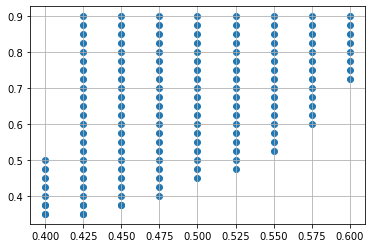

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
plt.scatter(exc, inh)

In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
dur = 100
dur_pre = 10
dur_post = 10

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[2] == '0':
    cntrl_vars_0 = [0,1]
elif case[2] == '1':
    cntrl_vars_0 = [2,3,4,5]
    
if case[3] == '0':
    maxC = [5., -5., 0.18, 0.]
elif case[3] == '1':
    maxC = [500., -500., 18., 0.]
    
if case[4] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[4] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[4] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[4] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

prec_vars = [0]
trans_time = 0.8
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [8]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'

In [9]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [10]:
i_stepsize = 10
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
-------  40 0.5500000000000003 0.5250000000000002
-------  50 0.5000000000000002 0.5750000000000003
-------  60 0.4250000000000001 0.6250000000000003
-------  70 0.5000000000000002 0.6500000000000004
-------  80 0.5750000000000002 0.6750000000000004
-------  90 0.47500000000000014 0.7250000000000004
-------  100 0.5250000000000001 0.7500000000000004
-------  110 0.5750000000000002 0.7750000000000005
-------  120 0.4250000000000001 0.8250000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  140 0.5250000000000001 0.8750000000000006
-------  150 0.5750000000000002 0.9000000000000006


In [11]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  10  20  30  40  50  60  70  80  90 100 110 120 130 140 150]


In [12]:
factor_iteration = 10.

data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i])
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    weights_init[i] = cost.getParams()

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]
    
##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1597.4109736505836
RUN  2 , total integrated cost =  544.6226396183066
RUN  3 , total integrated cost =  381.64393949114054
RUN  4 , total integrated cost =  232.46534562869283
RUN  5 , total integrated cost =  143.00481133451007
RUN  6 , total integrated cost =  50.32419393467359
RUN  7 , total integrated cost =  40.21391216898711
RUN  8 , total integrated cost =  36.11072927592799
RUN  9 , total integrated cost =  33.83241770512282
RUN  10 , total integrated cost =  32.25388693191771
RUN  11

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  14.917913684693126
RUN  1000 , total integrated cost =  14.917913684693126
Improved over  1000  iterations in  28.514426425099373  seconds by  99.74725709357418  percent.
Problem in initial value trasfer:  Vmean_exc -56.62760785616244 -56.62760821915662
weight =  3956.5897778954745
set cost params:  1.0 0.0 3956.5897778954745
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5896.049392242617
Gradient descend method:  None
RUN  1 , total integrated cost =  5707.742440224758
RUN  2 , total integrated cost =  5703.827010668953
RUN  3 , total integrated cost =  5647.131075931813
RUN  4 , total integrated cost =  5634.259468011561
RUN  5 , total integrated cost =  5634.177049656929
RUN  6 , total integrated cost =  5634.136736511957
RUN  7 , total integrated cost =  5634.08041890101
RUN  8 , total integrated cost =  5633.796288503351
RUN  9 , total integrated cost =  5600.780467711017
RUN  10 , total integrated cost =  5591.8854914

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  5591.783034370146
Control only changes marginally.
RUN  24 , total integrated cost =  5591.783034370096
Improved over  24  iterations in  0.5172417834401131  seconds by  5.1605123639710655  percent.
Problem in initial value trasfer:  Vmean_exc -56.627081411802145 -56.62708071191495
-------  10 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  0 , total integrated cost =  5097.289828199723
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5097.289828199723
Gradient descend method:  None
RUN  1 , total integrated cost =  1584.168404036671
RUN  2 , total integrated cost =  1492.4296382018115
RUN  3 , total integrated cost =  1369.5524896899317
RUN  4 , total integrated cost =  1288.574446344559
RU

...

Control only changes marginally.
RUN  24 , total integrated cost =  33336.38211159806
Improved over  24  iterations in  0.5369219612330198  seconds by  1.619748916317775  percent.
Problem in initial value trasfer:  Vmean_exc -56.703343642731404 -56.703343698745
-------  120 0.4250000000000001 0.8250000000000005
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879790712
Gradient descend method:  None
RUN  0 , total integrated cost =  5845.286879790712
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5845.286879790712
Gradient descend method:  None
RUN  1 , total integrated cost =  5845.286879790712
Control only changes marginally.
RUN  1 , total integrated cost =  5845.286879790712
Improved over  1  iterations in  0.04033738933503628  seconds by  0.0  percent.
weight =  10.0
set cost params:  1.0 0.0 10.0
inter

ERROR:root:Problem in initial value trasfer


RUN  1000 , total integrated cost =  27.36080214822068
RUN  1000 , total integrated cost =  27.36080214822068
Improved over  1000  iterations in  19.083877434954047  seconds by  99.91781087459285  percent.
Problem in initial value trasfer:  Vmean_exc -56.70353943719697 -56.70353970283765
weight =  12167.059754511849
set cost params:  1.0 0.0 12167.059754511849
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33276.030456496104
Gradient descend method:  None
RUN  1 , total integrated cost =  32918.3360996858
RUN  2 , total integrated cost =  32917.981746881975
RUN  3 , total integrated cost =  32917.644536943546
RUN  4 , total integrated cost =  32911.946056818444
RUN  5 , total integrated cost =  32888.886406049874
RUN  6 , total integrated cost =  32886.693435127636
RUN  7 , total integrated cost =  32886.43956487659
RUN  8 , total integrated cost =  32886.252542307935
RUN  9 , total integrated cost =  32885.23711984343
RUN  10 , total integrated cost =  32814.0

ERROR:root:Problem in initial value trasfer


RUN  40 , total integrated cost =  32662.440082316578
Control only changes marginally.
RUN  45 , total integrated cost =  32662.44007928047
Improved over  45  iterations in  0.9473388846963644  seconds by  1.8439410254111266  percent.
Problem in initial value trasfer:  Vmean_exc -56.703541728766616 -56.703541812664476


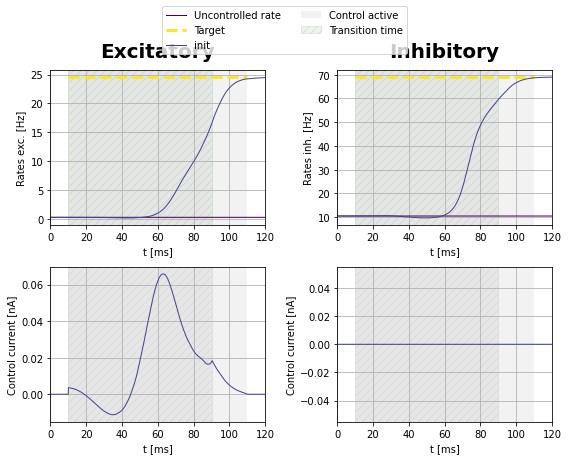

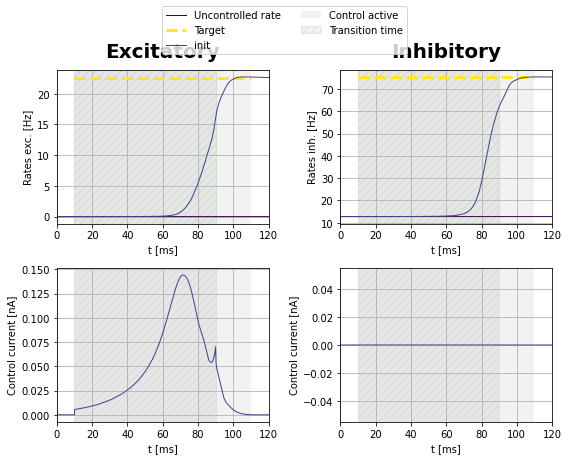

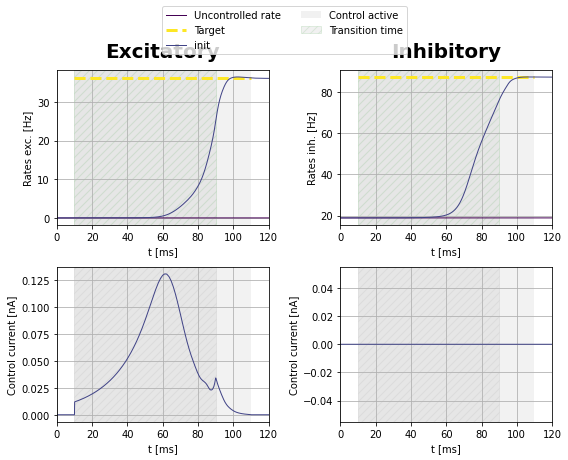

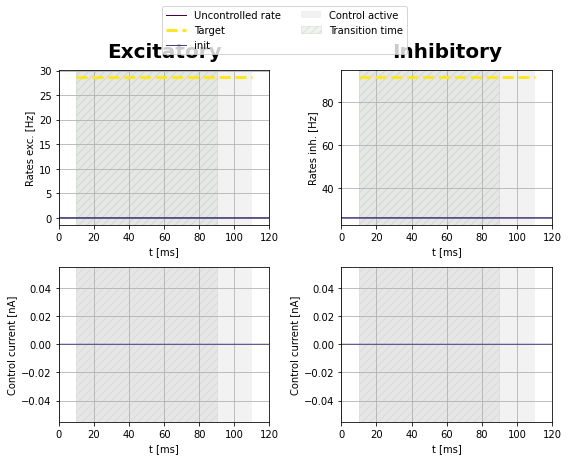

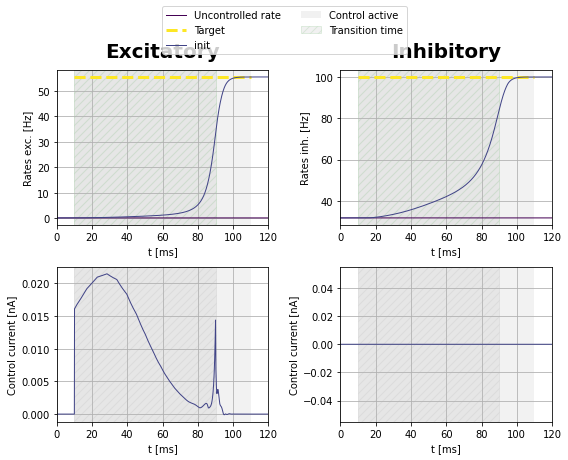

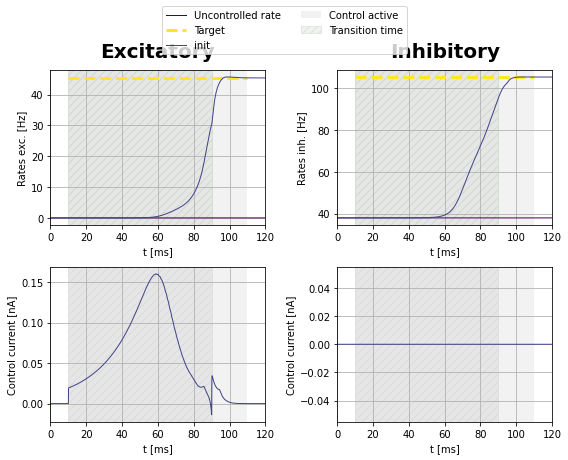

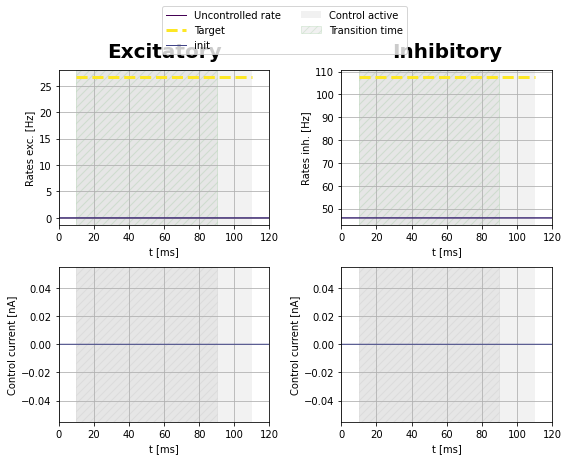

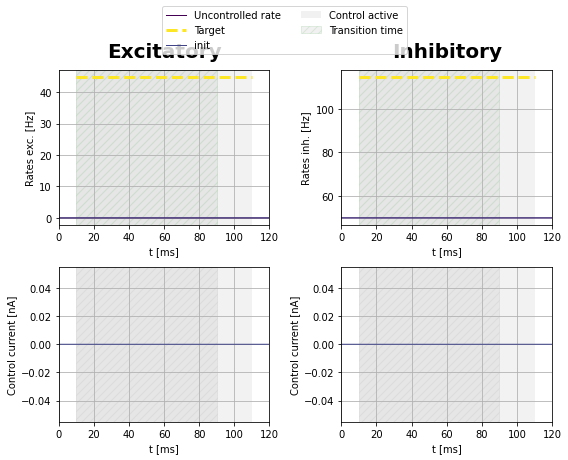

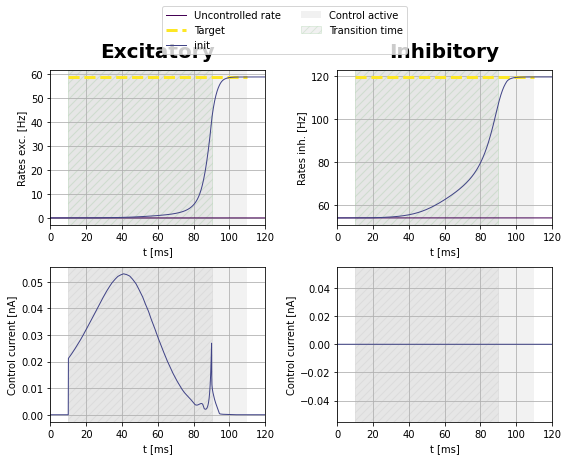

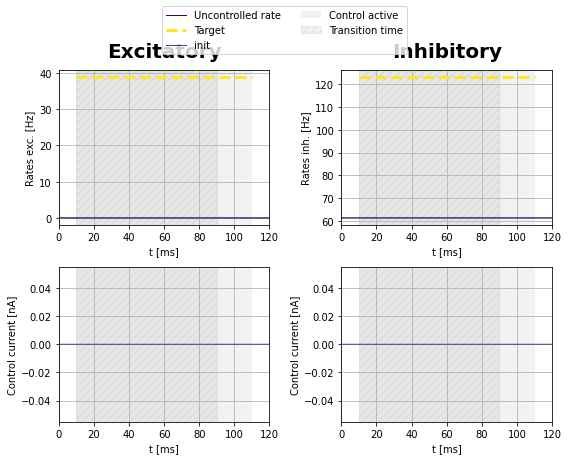

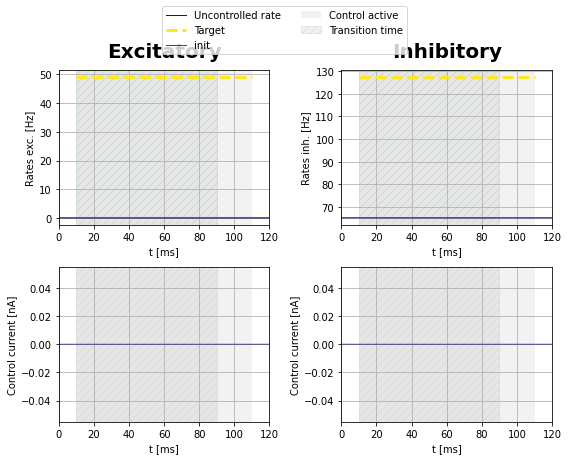

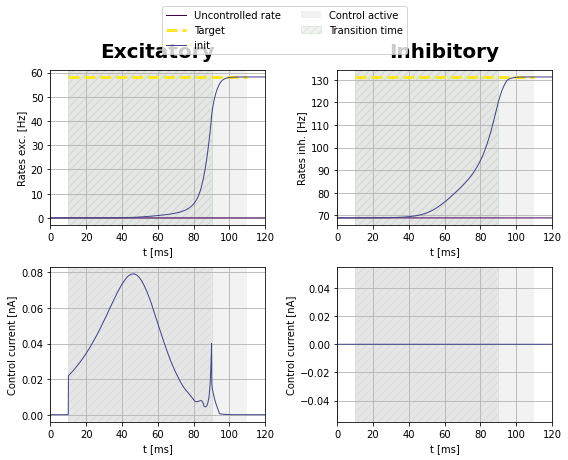

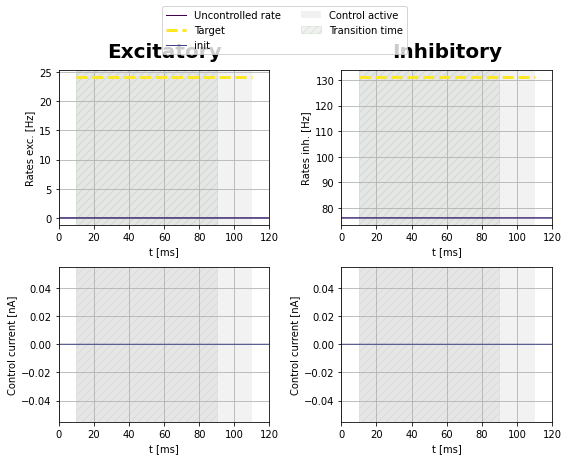

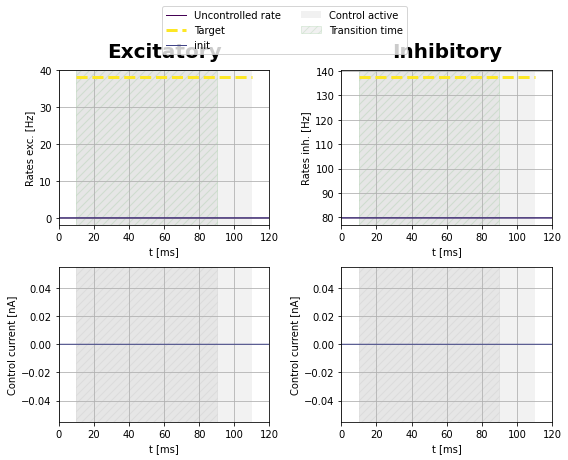

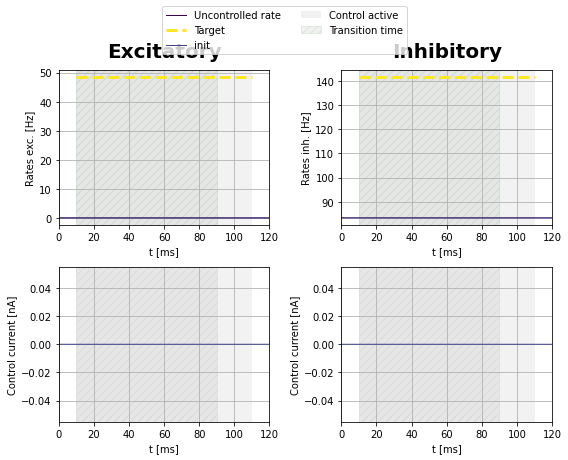

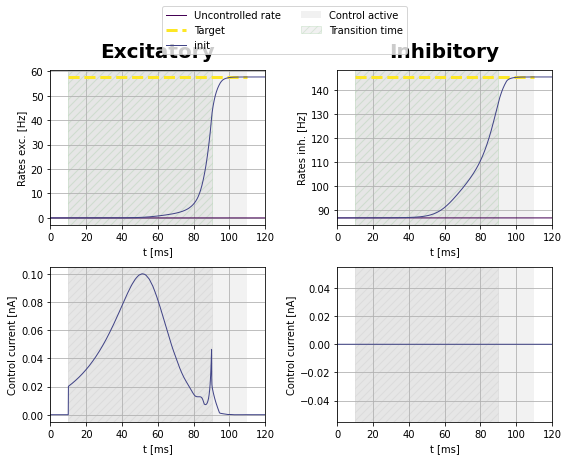

In [13]:
#plot initial guesses

for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [14]:
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
        
    if np.abs(cost_uncontrolled[i] - costnode_init[i][0][0][0]) > 1.:
        continue
        
    print("no solution found for ", i)
    
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    if i != 0:
        control0 = bestControl_init[i-2*i_stepsize][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
-------  10 0.4000000000000001 0.40000000000000013
-------  20 0.4500000000000001 0.4500000000000002
-------  30 0.4250000000000001 0.5000000000000002
no solution found for  30
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  8263.176035878749
Gradient descend method:  None
RUN  1 , total integrated cost =  8238.27582715419
RUN  2 , total integrated cost =  8232.032094913335
RUN  3 , total integrated cost =  8231.910070093756
RUN  4 , total integrated cost =  8231.907232809697
RUN  5 , total integrated cost =  8231.90722205159
RUN  6 , total integrated cost =  8231.907221489879
RUN  7 , total integrated cost =  8231.907221468233
RUN  8 , total integrated cost =  8231.907221468142
RUN  9 , total integrated cost =  8231.907221468138
RUN  10 , total integrated cost =  8231.907221468136
RUN  11 , total integrated cost =  8231.907221468136
Control only changes marginally.
RUN  11 , total i

ERROR:root:Problem in initial value trasfer


RUN  30 , total integrated cost =  7064.538114067198
Control only changes marginally.
RUN  30 , total integrated cost =  7064.538114067198
Improved over  30  iterations in  0.66875109821558  seconds by  0.6791295929723589  percent.
Problem in initial value trasfer:  Vmean_exc -56.632540916462766 -56.632519217317736
-------  70 0.5000000000000002 0.6500000000000004
no solution found for  70
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20107.273465622075
Gradient descend method:  None
RUN  1 , total integrated cost =  3062.933833545378
RUN  2 , total integrated cost =  1082.8508060055158
RUN  3 , total integrated cost =  726.5031046900206
RUN  4 , total integrated cost =  510.4522138977086
RUN  5 , total integrated cost =  391.45996037613475
RUN  6 , total integrated cost =  305.10724135965177
RUN  7 , total integrated cost =  259.6649929908434
RUN  8 , total integrated cost =  226.74213007693874
RUN  9 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  64 , total integrated cost =  18480.586212069476
Improved over  64  iterations in  1.2393122352659702  seconds by  7.907039410303014  percent.
Problem in initial value trasfer:  Vmean_exc -56.69517624347367 -56.69517638891334
-------  80 0.5750000000000002 0.6750000000000004
-------  90 0.47500000000000014 0.7250000000000004
no solution found for  90
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  15190.612217842709
Gradient descend method:  None
RUN  1 , total integrated cost =  15148.380094307446
RUN  2 , total integrated cost =  15143.817132090706
RUN  3 , total integrated cost =  15143.756094660701
RUN  4 , total integrated cost =  15143.75514095084
RUN  5 , total integrated cost =  15143.755111147484
RUN  6 , total integrated cost =  15143.755110309272
RUN  7 , total integrated cost =  15143.755110304543
RUN  8 , total integrated cost =  15143.755110304463
RUN  9 , total integrated cost = 

...

Control only changes marginally.
RUN  94 , total integrated cost =  14530.308130380634
Improved over  94  iterations in  1.7846785932779312  seconds by  0.11429616698585221  percent.
Problem in initial value trasfer:  Vmean_exc -56.67725791391218 -56.67725856493045
-------  140 0.5250000000000001 0.8750000000000006
no solution found for  140
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  271.9999754986463
Gradient descend method:  None
RUN  1 , total integrated cost =  106.89430466141762
RUN  2 , total integrated cost =  93.15502031842583
RUN  3 , total integrated cost =  89.23299206376163
RUN  4 , total integrated cost =  87.53988975880728
RUN  5 , total integrated cost =  86.57178460541243
RUN  6 , total integrated cost =  85.94443792450714
RUN  7 , total integrated cost =  85.48700704874037
RUN  8 , total integrated cost =  85.12821306660022
RUN  9 , total integrated cost =  84.82542676616929
RUN  10 , total integrated cost =  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  295 , total integrated cost =  47.57316732656301
Improved over  295  iterations in  5.459122722968459  seconds by  82.5098633779841  percent.
Problem in initial value trasfer:  Vmean_exc -56.70067706960211 -56.70067705332701
weight =  4946.619589474816
set cost params:  1.0 0.0 4946.619589474816
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23528.272349586536
Gradient descend method:  None
RUN  1 , total integrated cost =  23413.301448314614
RUN  2 , total integrated cost =  23413.223791352164
RUN  3 , total integrated cost =  23413.223656359358
RUN  4 , total integrated cost =  23413.22365089433
RUN  5 , total integrated cost =  23413.223650894328
RUN  6 , total integrated cost =  23413.22365089432


ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  23413.22365089432
Control only changes marginally.
RUN  7 , total integrated cost =  23413.22365089432
Improved over  7  iterations in  0.20424106158316135  seconds by  0.4889806483995329  percent.
Problem in initial value trasfer:  Vmean_exc -56.70066649505746 -56.70066684858275
-------  150 0.5750000000000002 0.9000000000000006


In [22]:
for k in range(10):

    factor_iteration = 10

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


-------  0 0.4000000000000001 0.3500000000000001
weight =  4180.386777132226
set cost params:  1.0 0.0 4180.386777132226
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5900.994888588239
Gradient descend method:  None
RUN  1 , total integrated cost =  5900.994888588239
Control only changes marginally.
RUN  1 , total integrated cost =  5900.994888588239
Improved over  1  iterations in  0.08286742307245731  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.627014259290476 -56.627012751789586
-------  10 0.4000000000000001 0.40000000000000013
weight =  1557.7562112806233
set cost params:  1.0 0.0 1557.7562112806233
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5094.0197274672855
Gradient descend method:  None
RUN  1 , total integrated cost =  5094.0197274672855
Control only changes marginally.
RUN  1 , total integrated cost =  5094.0197274672855
Improved over  1  iterations in  0.07426490634679794  seconds by  0.0 

ERROR:root:Problem in initial value trasfer
ERROR:root:Cost parameter I_s smaller 0 not allowed, use default instead


RUN  1 , total integrated cost =  13014.910050755581
Control only changes marginally.
RUN  1 , total integrated cost =  13014.910050755581
Improved over  1  iterations in  0.07555138505995274  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67116014510268 -56.671144793265604
-------  30 0.4250000000000001 0.5000000000000002
weight =  -1.0
set cost params:  1.0 -0.0 -1.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6.486677621699579
Gradient descend method:  None
RUN  1 , total integrated cost =  6.486635330801279
RUN  2 , total integrated cost =  6.4864557248158246
RUN  3 , total integrated cost =  6.486364890796065
RUN  4 , total integrated cost =  6.486345845932621
RUN  5 , total integrated cost =  6.486296357425752
RUN  6 , total integrated cost =  6.48627220362674
RUN  7 , total integrated cost =  6.4859993213505165
RUN  8 , total integrated cost =  6.485855170199057
RUN  9 , total integrated cost =  6.485811189124677
RUN  10 , 

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


...

RUN  1 , total integrated cost =  15137.380407628578
Control only changes marginally.
RUN  1 , total integrated cost =  15137.380407628578
Improved over  1  iterations in  0.06925311870872974  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.68022149680715 -56.68021158192714
-------  100 0.5250000000000001 0.7500000000000004
weight =  5659.42036924627
set cost params:  1.0 0.0 5659.42036924627
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24124.179843491485
Gradient descend method:  None
RUN  1 , total integrated cost =  24124.179843491485
Control only changes marginally.
RUN  1 , total integrated cost =  24124.179843491485
Improved over  1  iterations in  0.06998292915523052  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.701400251408 -56.70140056504387
-------  110 0.5750000000000002 0.7750000000000005
weight =  15502.393211519804
set cost params:  1.0 0.0 15502.393211519804
interpolate adjoint :  True Tr

ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  5836.713226952515
Control only changes marginally.
RUN  1 , total integrated cost =  5836.713226952515
Improved over  1  iterations in  0.06804662384092808  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62443875555312 -56.62443434036976
-------  130 0.47500000000000014 0.8500000000000005
weight =  2179.2307659271537
set cost params:  1.0 0.0 2179.2307659271537
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14541.306364819613
Gradient descend method:  None
RUN  1 , total integrated cost =  14541.306364819613
Control only changes marginally.
RUN  1 , total integrated cost =  14541.306364819613
Improved over  1  iterations in  0.06882923096418381  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67725785196406 -56.67725850445371
-------  140 0.5250000000000001 0.8750000000000006
weight =  4970.914582804024
set cost params:  1.0 0.0 4970.914582804024
interpolate adjoint :  True

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.367237180064
Control only changes marginally.
RUN  1 , total integrated cost =  33287.367237180064
Improved over  1  iterations in  0.0706433467566967  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.703541749222374 -56.70354183216586


In [23]:
with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

In [17]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [24]:
factor_iteration = 10
    
for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i])
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i])
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  144.73796980980134
Gradient descend method:  None
RUN  1 , total integrated cost =  25.975689333241462
RUN  2 , total integrated cost =  22.020374628630588
RUN  3 , total integrated cost =  19.236215615726145
RUN  4 , total integrated cost =  18.405032419618067
RUN  5 , total integrated cost =  17.56541201028481
RUN  6 , total integrated cost =  17.119173861776925
RUN  7 , total integrated cost =  16.601737686156337
RUN  8 , total integrated cost =  16.28777504804018
RUN  9 , total integrated cost =  15.71476030003976
RUN  10 , total integrated cost =  15.440903046115526
RUN  11 , total integrated cost =  14.905682484901206
RUN  12 , total integrated cost =  14.836102406577826
RUN  13 , total integrated cost =  14.817795369398072
RUN  14 , total integrated cost =  14.80078878285875
RUN  15 , total integrated cost =  14.792569620473952
R

ERROR:root:Problem in initial value trasfer


RUN  500 , total integrated cost =  14.140074964049335
RUN  500 , total integrated cost =  14.140074964049335
Improved over  500  iterations in  22.066539458930492  seconds by  90.2305697788696  percent.
Problem in initial value trasfer:  Vmean_exc -56.62762157819746 -56.62762155722336
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  141.29971447662237
Gradient descend method:  HS
RUN  1 , total integrated cost =  141.0746769045954
RUN  2 , total integrated cost =  140.7936933185686
RUN  3 , total integrated cost =  140.7828134379535
RUN  4 , total integrated cost =  140.70016591973226
RUN  5 , total integrated cost =  140.69052154540424
RUN  6 , total integrated cost =  140.67666195786214
RUN  7 , total integrated cost =  140.65180368426763
RUN  8 , total integrated cost =  140.63320830858112
RUN  9 , total integrated cost =  140.60628469792243
RUN  10 , total integrated cost =  140.0469457758084
RUN  11 , total inte

ERROR:root:Problem in initial value trasfer


State only changes marginally.
Control only changes marginally.
RUN  64 , total integrated cost =  4777.139022337619
Improved over  64  iterations in  3.846526350826025  seconds by  18.9332045126432  percent.
Problem in initial value trasfer:  Vmean_exc -56.626495356337465 -56.62650422208805
-------  10 0.4000000000000001 0.40000000000000013
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  73.52828700475851
Gradient descend method:  None
RUN  1 , total integrated cost =  50.751375522106486
RUN  2 , total integrated cost =  46.171924247958955
RUN  3 , total integrated cost =  42.65133480781874
RUN  4 , total integrated cost =  41.20822478611893
RUN  5 , total integrated cost =  39.7978419306499
RUN  6 , total integrated cost =  39.32682021760325
RUN  7 , total integrated cost =  38.72996151645165
RUN  8 , total integrated cost =  38.48577548238202
RUN  9 , total integrated cost =  38.05050898079225
RUN  10 , total integrated cost =  

...

Control only changes marginally.
RUN  214 , total integrated cost =  27.087563548161445
Improved over  214  iterations in  22.324378916993737  seconds by  86.60839079878491  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354229213901 -56.70354226493076
weight =  100
set cost params:  1.0 0.0 100.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  270.83110392486657
Gradient descend method:  HS
RUN  1 , total integrated cost =  270.7408209088089
RUN  2 , total integrated cost =  270.2195647082817
RUN  3 , total integrated cost =  270.21560788034225
RUN  4 , total integrated cost =  269.9967830439008
RUN  5 , total integrated cost =  269.9967830439006


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  269.9967830439005
RUN  7 , total integrated cost =  269.9967830439005
Control only changes marginally.
RUN  7 , total integrated cost =  269.9967830439005
Improved over  7  iterations in  0.9195663891732693  seconds by  0.30805947650588905  percent.
Problem in initial value trasfer:  Vmean_exc -56.703543880587205 -56.70354374002865
weight =  12328.795596662674
set cost params:  1.0 0.0 12328.795596662674
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33262.53749162888
Gradient descend method:  None
RUN  1 , total integrated cost =  32969.06574704041
RUN  2 , total integrated cost =  32968.98754421845
RUN  3 , total integrated cost =  32968.97723844727
RUN  4 , total integrated cost =  32968.974895964915
RUN  5 , total integrated cost =  32968.97421514252
RUN  6 , total integrated cost =  32968.97412417529
RUN  7 , total integrated cost =  32968.974121259555
RUN  8 , total integrated cost =  32968.97412118409
RUN  9 , total inte

ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  32968.97412118324
RUN  12 , total integrated cost =  32968.97412118324
Control only changes marginally.
RUN  12 , total integrated cost =  32968.97412118324
Improved over  12  iterations in  1.5791325122117996  seconds by  0.8825645683812411  percent.
Problem in initial value trasfer:  Vmean_exc -56.703545142425924 -56.70354494701122


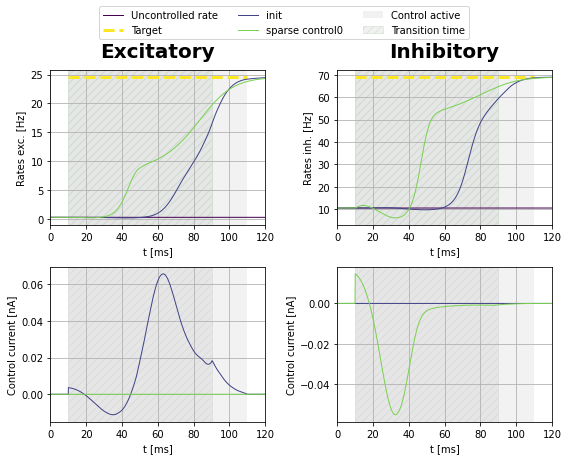

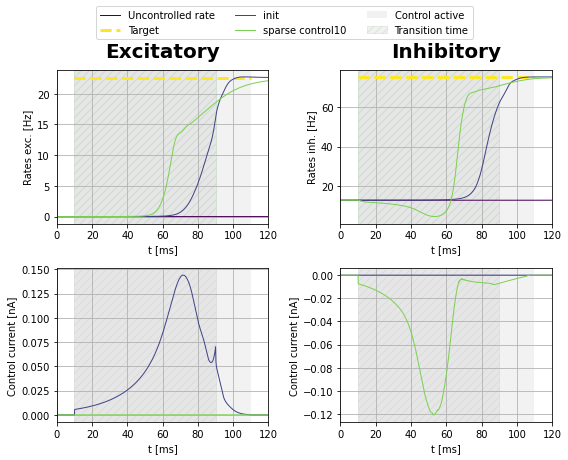

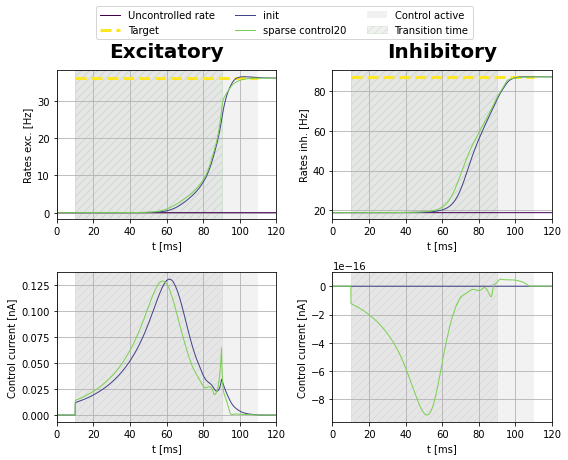

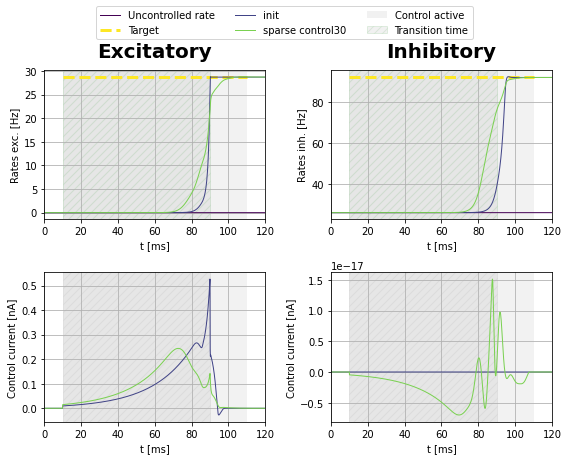

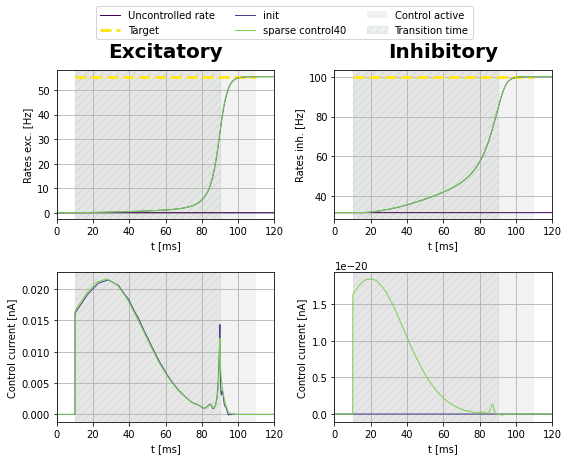

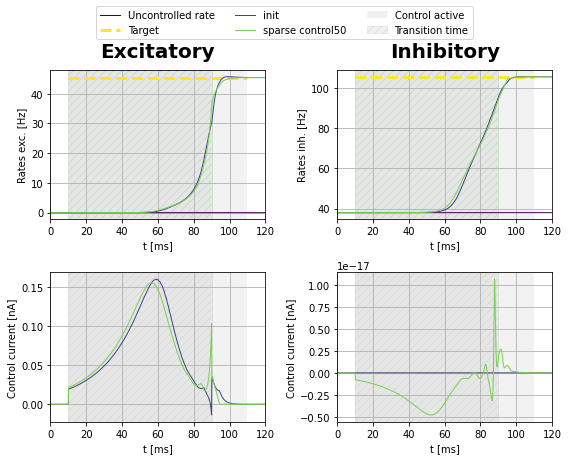

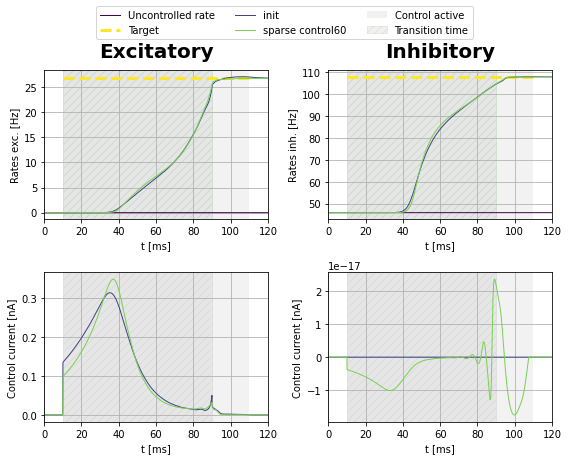

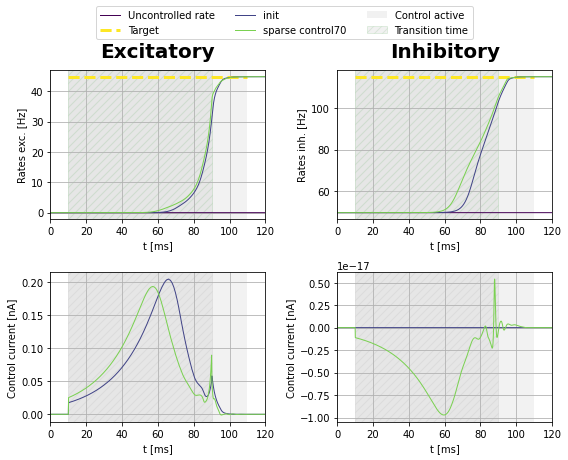

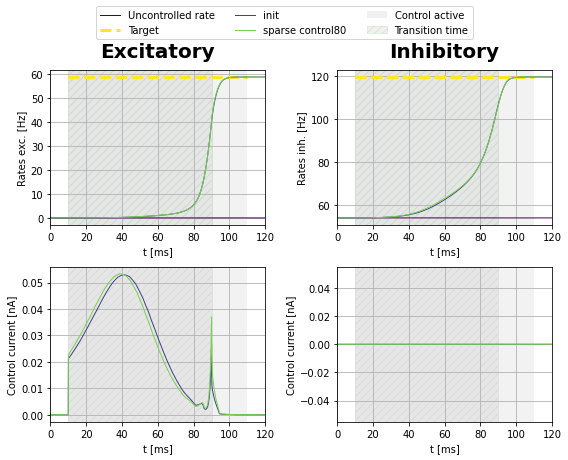

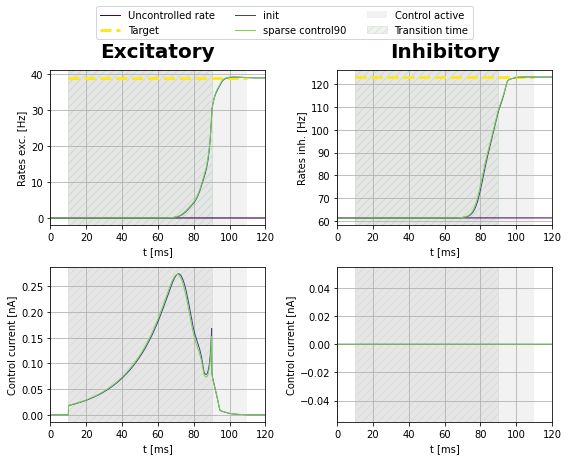

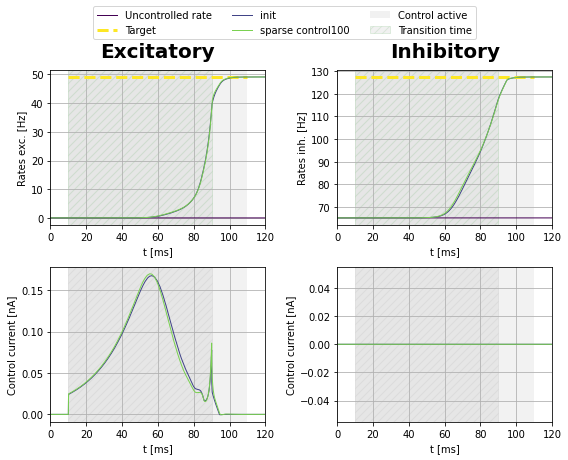

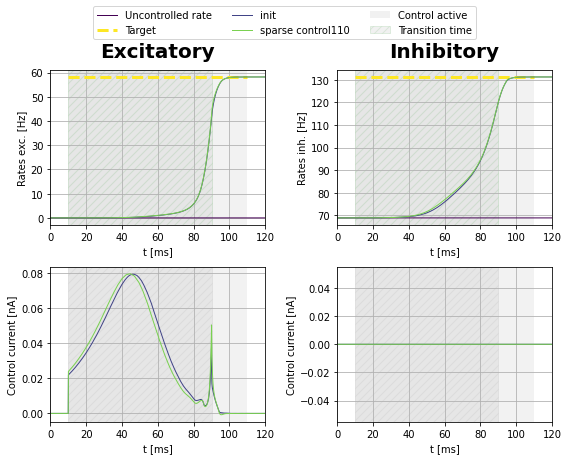

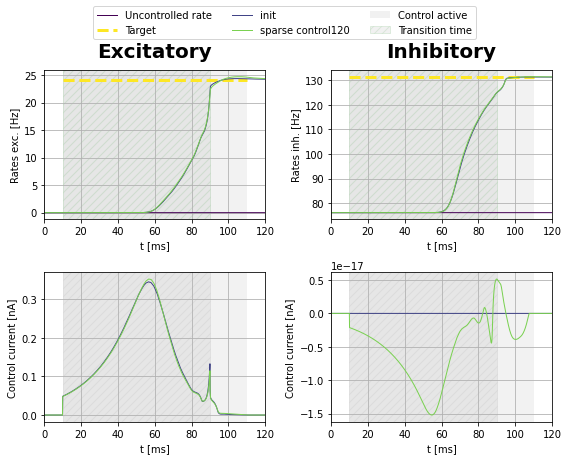

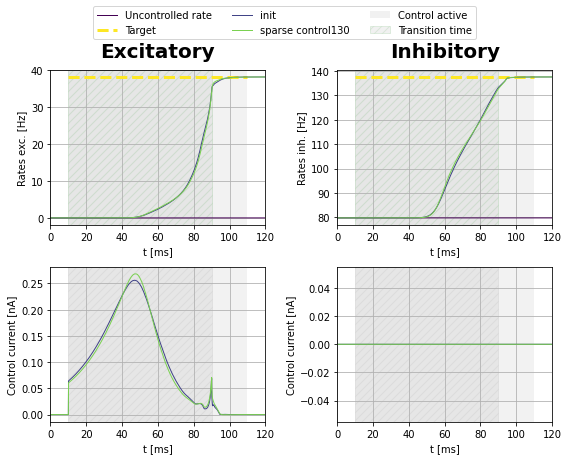

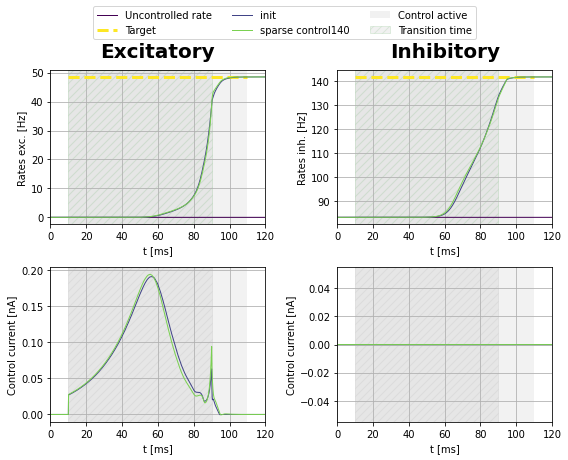

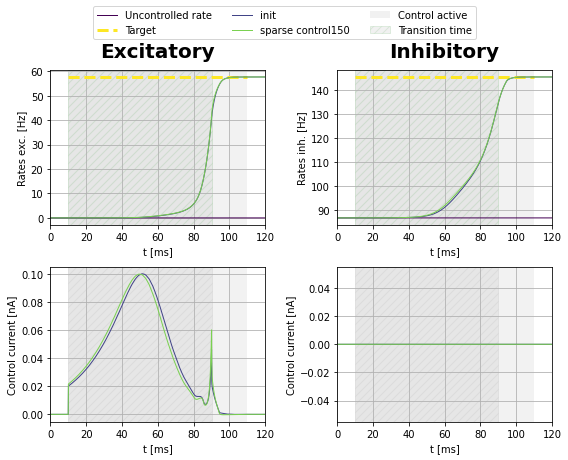

In [19]:
for i in i_range:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [25]:
factor_iteration = 10

for k in range(10):
    for i in i_range:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i])
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
weight =  5833.506121619643
set cost params:  1.0 0.0 5833.506121619643
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5884.805981746449
Gradient descend method:  None
RUN  1 , total integrated cost =  5883.794673370511
RUN  2 , total integrated cost =  5883.794673370505
RUN  3 , total integrated cost =  5883.794673370503


ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  5883.7946733705
RUN  5 , total integrated cost =  5883.7946733705
Control only changes marginally.
RUN  5 , total integrated cost =  5883.7946733705
Improved over  5  iterations in  0.8320078998804092  seconds by  0.0171850759241039  percent.
Problem in initial value trasfer:  Vmean_exc -56.626408381377054 -56.62641798981444
-------  10 0.4000000000000001 0.40000000000000013
weight =  2083.5410414977023
set cost params:  1.0 0.0 2083.5410414977023
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5076.843283284582
Gradient descend method:  None
RUN  1 , total integrated cost =  5075.596100968173
RUN  2 , total integrated cost =  5075.590609028835
RUN  3 , total integrated cost =  5075.590542168342
RUN  4 , total integrated cost =  5075.59054163664
RUN  5 , total integrated cost =  5075.590541634798
RUN  6 , total integrated cost =  5075.590541634771
RUN  7 , total integrated cost =  5075.5905416347705
RUN  8 , total integrated cos

ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  5075.590541634767
Control only changes marginally.
RUN  10 , total integrated cost =  5075.590541634767
Improved over  10  iterations in  1.1054700165987015  seconds by  0.024675602139225816  percent.
Problem in initial value trasfer:  Vmean_exc -56.62571418591133 -56.62569323429141
-------  20 0.4500000000000001 0.4500000000000002
weight =  4160.702201448135
set cost params:  1.0 0.0 4160.702201448135
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13014.408142375714
Gradient descend method:  None
RUN  1 , total integrated cost =  13014.406408567273
RUN  2 , total integrated cost =  13014.406264045636
RUN  3 , total integrated cost =  13014.406214859211
RUN  4 , total integrated cost =  13014.406208501021
RUN  5 , total integrated cost =  13014.406207874586
RUN  6 , total integrated cost =  13014.406207810696
RUN  7 , total integrated cost =  13014.406207802309
RUN  8 , total integrated cost =  13014.406207801345
RUN  9 , tota

...

RUN  0 , total integrated cost =  14541.32861312816
Gradient descend method:  None
RUN  1 , total integrated cost =  14541.32861312816
Control only changes marginally.
RUN  1 , total integrated cost =  14541.32861312816
Improved over  1  iterations in  0.1840048599988222  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67721808315749 -56.67721992951875
-------  140 0.5250000000000001 0.8750000000000006
weight =  4979.0772221846655
set cost params:  1.0 0.0 4979.0772221846655
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23527.910787423138
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23527.910787423138
Control only changes marginally.
RUN  1 , total integrated cost =  23527.910787423138
Improved over  1  iterations in  0.18680166080594063  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.700673378211626 -56.70067351846965
-------  150 0.5750000000000002 0.9000000000000006
weight =  12448.393376667904
set cost params:  1.0 0.0 12448.393376667904
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  33287.37743687002
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  33287.37743687002
Control only changes marginally.
RUN  1 , total integrated cost =  33287.37743687002
Improved over  1  iterations in  0.19191028364002705  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70354515335133 -56.703544957494685


In [26]:
with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)